# Prepare Local Database for Router Training

This notebook fetches all profiling data from PostgreSQL once and saves it to a local SQLite database.

## Purpose

Instead of hitting the remote PostgreSQL database every time you run a training notebook:
1. **Run this notebook ONCE** to download all data
2. Data is saved as a local SQLite file (`../data/vlm_router_cache.db`)
3. **Other notebooks load from local SQLite** - much faster!

## Benefits

✅ **Faster iterations** - No network latency  
✅ **Work offline** - No need for database connection  
✅ **Consistent data** - All notebooks use same snapshot  
✅ **No database load** - Don't stress production database  

## Output

Creates `../data/vlm_router_cache.db` with:
- All profiling data from PostgreSQL
- Data validation and cleaning applied
- Ready to use in notebooks 02, 03, 04

## 1. Setup

In [17]:
# === Path Setup ===
import sys
from pathlib import Path

# Notebook paths
NOTEBOOK_DIR = Path.cwd()
ARTEMIS_DIR = NOTEBOOK_DIR.parent.parent  # artemis_final/
ROOT_DIR = ARTEMIS_DIR.parent             # Which_VLM_Router/
ROUTER_TRAIN_DIR = ARTEMIS_DIR / 'router_train'

# Add to sys.path for imports
for p in [str(ARTEMIS_DIR), str(ROOT_DIR), str(ROUTER_TRAIN_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

print(f"📁 Setup complete")

%load_ext autoreload
%autoreload 2

📁 Setup complete
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
# Add parent directory to path
import sys
import os

import logging
from pathlib import Path
print(str(Path(os.getcwd()).parent.parent))
# Add artemis_final to path
sys.path.insert(0, str(Path(os.getcwd()).parent.parent))  # artemis_final/
# Also add router_train for local imports
sys.path.insert(0, str(Path(os.getcwd()).parent.parent / 'router_train'))

/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router/artemis_final


In [19]:

from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Local imports
from config import DBConfig
from db_utils import (
    load_profiles_real_schema,
    test_connection,
    save_to_sqlite,
    load_from_sqlite,
)
from training.data_validation import (
    validate_profiles_dataframe,
    clean_profiles_dataframe,
    validate_train_val_test_split,
)

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports successful")

✓ Imports successful


In [20]:
# Configuration
DATA_DIR = Path("../data")
DATA_DIR.mkdir(exist_ok=True)

# Output database path
LOCAL_DB_PATH = DATA_DIR / "vlm_router_cache.db"
TABLE_NAME = "vlm_profiles"
PARQUET_PATH = DATA_DIR / "router_profiles_with_utility.parquet"

# How much data to fetch (None = all data)
LIMIT = None  # Fetch all data for training
LIMIT_PER_SPLIT = False 

print("Configuration:")
print(f"  Local DB Path: {LOCAL_DB_PATH}")
print(f"  Parquet Path: {PARQUET_PATH}")
print(f"  Table Name: {TABLE_NAME}")
print(f"  Limit: {LIMIT}")
print(f"  Limit per split: {LIMIT_PER_SPLIT}")

Configuration:
  Local DB Path: ../data/vlm_router_cache.db
  Parquet Path: ../data/router_profiles_with_utility.parquet
  Table Name: vlm_profiles
  Limit: None
  Limit per split: False


## 2. Connect to PostgreSQL

In [21]:
# Load database configuration from environment
db_config = DBConfig.from_env()

print("[PostgreSQL Configuration]")
print(f"  Host: {db_config.host}")
print(f"  Port: {db_config.port}")
print(f"  Database: {db_config.name}")
print(f"  User: {db_config.user}")

# Test connection
print("\n[Testing Connection]")
if test_connection(db_config):
    print("✓ PostgreSQL connection successful!")
else:
    raise RuntimeError("PostgreSQL connection failed. Check credentials and network.")

# Schema Sanity Check
from sqlalchemy import text, inspect
from db_utils import get_engine

engine = get_engine(db_config)
inspector = inspect(engine)

print("\n[Schema Check]")
for table in ['vlm_samples', 'vlm_responses', 'vlm_evaluations']:
    if inspector.has_table(table):
        columns = [c['name'] for c in inspector.get_columns(table)]
        print(f"  ✓ Table found: {table} ({len(columns)} columns)")
        # Print first few columns
        print(f"    Cols: {columns[:5]} ...")
    else:
        print(f"  ❌ Table MISSING: {table}")
        
# Sample rows
print("\n[Sample Rows]")
with engine.connect() as conn:
    res = conn.execute(text("SELECT * FROM vlm_samples LIMIT 3"))
    print(f"  vlm_samples (3 rows): {res.rowcount}")
    res = conn.execute(text("SELECT * FROM vlm_responses LIMIT 3"))
    print(f"  vlm_responses (3 rows): {res.rowcount}")

2025-12-08 19:50:33,167 - db_utils - INFO - Created database engine for localhost:5432/vlmrouter
2025-12-08 19:50:33,192 - db_utils - INFO - Database connection test successful
2025-12-08 19:50:33,192 - db_utils - INFO - Created database engine for localhost:5432/vlmrouter


[PostgreSQL Configuration]
  Host: localhost
  Port: 5432
  Database: vlmrouter
  User: vlmrouter

[Testing Connection]
✓ PostgreSQL connection successful!

[Schema Check]
  ✓ Table found: vlm_samples (21 columns)
    Cols: ['sample_id', 'run_id', 'created_at', 'updated_at', 'source_config'] ...
  ✓ Table found: vlm_responses (55 columns)
    Cols: ['response_id', 'sample_id', 'model_name', 'model_prefix', 'model_id'] ...
  ✓ Table found: vlm_evaluations (20 columns)
    Cols: ['evaluation_id', 'sample_id', 'model_name', 'response_id', 'glider_score'] ...

[Sample Rows]
  vlm_samples (3 rows): 3
  vlm_responses (3 rows): 3


## 3. Fetch All Data from PostgreSQL

In [ ]:
# Load all data with filtering for non-empty responses/evals
from sqlalchemy import text
from db_utils import get_engine

print(f"\n{'='*80}")
print("FETCHING DATA FROM POSTGRESQL")
print(f"{'='*80}\n")

engine = get_engine(db_config)

# Construct query with new schema
query = """
SELECT
    -- sample-level
    s.sample_id,
    s.run_id,
    s.source_config,
    s.source_dataset,
    s.source_index,
    s.router_task,
    s.ground_truth_type,
    s.data_split,
    s.prompt_text,
    s.ground_truth,
    s.txt_prompt_length_chars,
    s.txt_prompt_length_words,
    s.txt_question_type,
    s.txt_has_mc_options,

    -- response-level
    r.response_id,
    r.model_name,
    r.model_prefix,
    r.ok,
    r.is_correct,
    r.score_exact_match_normalized,
    r.score_numeric_match,
    r.score_mc_letter_match,
    r.confidence_score,
    r.estimated_cost_usd,
    r.latency_ms,
    r.input_tokens,
    r.output_tokens,
    r.total_tokens,

    -- utility (NEW)
    r.utility_accuracy,
    r.utility_cheap,
    r.utility_fast,
    r.utility_balanced,
    r.cost_norm_new,
    r.lat_norm,

    -- evaluation-level
    ev.glider_score,
    ev.judge_molmo_score,
    ev.judge_molmo_rank_group

FROM vlm_samples s
JOIN vlm_responses r
  ON s.sample_id = r.sample_id
JOIN vlm_evaluations ev
  ON r.sample_id = ev.sample_id
 AND r.model_name = ev.model_name

WHERE 
    r.ok = TRUE
"""

if LIMIT and LIMIT > 0:
    query += f" LIMIT {LIMIT}"

print("[Executing Query]")
# Execute
try:
    df_all = pd.read_sql(text(query), engine)
    
    print(f"\n[Data Loaded]")
    print(f"  Total rows: {len(df_all):,}")
    if 'sample_id' in df_all.columns:
        print(f"  Unique samples: {df_all['sample_id'].nunique():,}")
    if 'model_name' in df_all.columns:
        print(f"  Unique models: {df_all['model_name'].nunique()}")
    
    if 'data_split' in df_all.columns:
        print(f"\n  Data split distribution:")
        for split, count in df_all['data_split'].value_counts().items():
            pct = 100 * count / len(df_all)
            print(f"    {split:6s}: {count:7,} ({pct:5.2f}%)")
            
except Exception as e:
    print(f"Error fetching data: {e}")
    # Fallback to empty df to prevent notebook crash
    df_all = pd.DataFrame()

2025-12-08 19:50:33,258 - db_utils - INFO - Created database engine for localhost:5432/vlmrouter



FETCHING DATA FROM POSTGRESQL

[Executing Query]

[Data Loaded]
  Total rows: 339,056
  Unique samples: 67,935
  Unique models: 5

  Data split distribution:
    train : 237,978 (70.19%)
    val   :  51,113 (15.08%)
    test  :  49,965 (14.74%)


In [23]:
# Preview data
print("[Data Preview]\n")
display(df_all.head())

print("\n[Data Info]")
print(df_all.info())

[Data Preview]



,sample_id,run_id,source_config,source_dataset,source_index,router_task,ground_truth_type,data_split,prompt_text,ground_truth,...,total_tokens,utility_accuracy,utility_cheap,utility_fast,utility_balanced,cost_norm_new,lat_norm,glider_score,judge_molmo_score,judge_molmo_rank_group
0,aokvqa_796_8644de03,run_20251207_225050,aokvqa,cauldron,796,knowledge_vqa,exact,test,How many women are holding umbrellas in front ...,Two.,...,493,0.0,0.986553,0.968584,0.488784,0.013447,0.031416,5.0,NaN,NaN
1,docvqa_270_ca57d063,run_20251207_225050,docvqa,cauldron,270,document_ocr,exact,train,What is the title of the document?\nEnsure bre...,Hazard and Exposure Criteria for Prioritizatio...,...,4876,0.0,0.866107,0.976502,0.460652,0.133893,0.023498,5.0,10.0,1.0
2,docvqa_780_af6b5410,run_20251207_225050,docvqa,cauldron,780,document_ocr,exact,train,What is the name of association in statement?\...,Food industry association.,...,3165,0.0,0.913126,0.952448,0.466393,0.086874,0.047552,5.0,9.0,1.0
3,hateful_memes_318_89d84476,run_20251207_225050,hateful_memes,cauldron,318,meme_classification,exact,train,Can this meme be interpreted as derogatory?\nA...,No.,...,647,0.0,0.982321,0.996046,0.494592,0.017679,0.003954,0.0,10.0,1.0
4,ai2d_585_e4327c29,run_20251208_023438,ai2d,cauldron,585,diagram_reasoning,mc,train,Question: At what stage does a butterfly lay e...,Answer: C,...,115,0.0,0.996940,0.986229,0.495792,0.003060,0.013771,4.0,10.0,1.0



[Data Info]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339056 entries, 0 to 339055
Data columns (total 37 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   sample_id                     339056 non-null  object 
 1   run_id                        339056 non-null  object 
 2   source_config                 339056 non-null  object 
 3   source_dataset                339056 non-null  object 
 4   source_index                  339056 non-null  int64  
 5   router_task                   339056 non-null  object 
 6   ground_truth_type             339056 non-null  object 
 7   data_split                    339056 non-null  object 
 8   prompt_text                   339056 non-null  object 
 9   ground_truth                  339056 non-null  object 
 10  txt_prompt_length_chars       339056 non-null  int64  
 11  txt_prompt_length_words       339056 non-null  int64  
 12  txt_question_type             2

## 4. Validate and Clean Data

In [24]:
# Filter and Validate
print(f"\n{'='*80}")
print("FILTERING AND VALIDATION")
print(f"{'='*80}\n")

initial_len = len(df_all)

# 1. Filter: ok=True
df_filtered = df_all[df_all['ok'] == True].copy()
dropped_ok = initial_len - len(df_filtered)
print(f"Dropped {dropped_ok:,} rows where ok != True")

# 2. Filter: utility_accuracy is not null
before_util = len(df_filtered)
df_filtered = df_filtered.dropna(subset=['utility_accuracy'])
dropped_util = before_util - len(df_filtered)
print(f"Dropped {dropped_util:,} rows where utility_accuracy is NaN")

# 3. Assertions
if len(df_filtered) > 0:
    # Uniqueness check
    dups = df_filtered.duplicated(subset=['sample_id', 'model_name']).sum()
    if dups > 0:
        print(f"WARNING: Found {dups} duplicate (sample_id, model_name) pairs. Dropping.")
        df_filtered = df_filtered.drop_duplicates(subset=['sample_id', 'model_name'])
    
    assert df_filtered['sample_id'].notnull().all(), "Null sample_id"
    assert df_filtered['model_name'].notnull().all(), "Null model_name"
    assert df_filtered['utility_accuracy'].notnull().all(), "Null utility_accuracy"

print(f"Final working rows: {len(df_filtered):,}")

# Use the filtered dataframe for validation and cleaning
validation_report = validate_profiles_dataframe(
    df=df_filtered,
    allow_missing_images=True,
    allow_missing_confidence=True,
    max_missing_cost_pct=10.0,
    max_missing_latency_pct=10.0,
    max_missing_glider_pct=5.0,
)

print(f"\n{'='*80}")
print("VALIDATION REPORT")
print(f"{'='*80}")
print(f"  Total rows: {validation_report['total_rows']:,}")
print(f"  Validation passed: {validation_report['validation_passed']}")
print(f"  Errors: {len(validation_report['errors'])}")
print(f"  Warnings: {len(validation_report['warnings'])}")

if validation_report['errors']:
    print(f"\n  Errors:")
    for error in validation_report['errors']:
        print(f"    ❌ {error}")

if validation_report['warnings']:
    print(f"\n  Warnings (showing first 10):")
    for warning in validation_report['warnings'][:10]:
        print(f"    ⚠️  {warning}")

print(f"\n  Statistics:")
for key, value in validation_report['statistics'].items():
    if isinstance(value, dict):
        print(f"    {key}: {value}")
    elif isinstance(value, float):
        print(f"    {key}: {value:.2f}")
    else:
        print(f"    {key}: {value}")
print(f"{'='*80}")

if not validation_report['validation_passed']:
    print("\n⚠️  Data validation found critical issues. Review errors above.")
    print("    You may need to adjust validation thresholds or fix data quality.")

# Apply to clean step
df_all = df_filtered # Update global reference for next cells


FILTERING AND VALIDATION

Dropped 0 rows where ok != True
Dropped 0 rows where utility_accuracy is NaN
Final working rows: 339,056


2025-12-08 19:50:37,936 - training.data_validation - INFO - ✓ Data validation PASSED



VALIDATION REPORT
  Total rows: 339,056
  Validation passed: True
  Errors: 0
  Warnings: 0

  Statistics:
    estimated_cost_usd_missing_pct: 0.00
    latency_ms_missing_pct: 0.00
    glider_score_missing_pct: 0.00
    confidence_missing_pct: 0.00
    unique_samples: 67935
    unique_models: 5
    data_split_counts: {'train': 237978, 'val': 51113, 'test': 49965}


In [25]:
# Clean data
print(f"\n{'='*80}")
print("DATA CLEANING")
print(f"{'='*80}\n")

df_clean, cleaning_stats = clean_profiles_dataframe(
    df=df_all,
    fill_missing_cost=True,
    fill_missing_latency=True,
    fill_missing_confidence=True,
    drop_missing_glider=True,
    drop_duplicates=True,
)

print(f"\n{'='*80}")
print("CLEANING SUMMARY")
print(f"{'='*80}")
print(f"  Initial rows:        {cleaning_stats['initial_rows']:,}")
print(f"  Final rows:          {cleaning_stats['final_rows']:,}")
print(f"  Dropped rows:        {cleaning_stats['dropped_rows']:,} ({100*cleaning_stats['dropped_rows']/cleaning_stats['initial_rows']:.2f}%)")

if 'dropped_duplicates' in cleaning_stats:
    print(f"\n  Dropped duplicates:  {cleaning_stats['dropped_duplicates']:,}")
if 'dropped_missing_glider' in cleaning_stats:
    print(f"  Dropped missing glider: {cleaning_stats['dropped_missing_glider']:,}")
if 'filled_cost' in cleaning_stats:
    print(f"  Filled costs:        {cleaning_stats['filled_cost']:,}")
if 'filled_latency' in cleaning_stats:
    print(f"  Filled latencies:    {cleaning_stats['filled_latency']:,}")
if 'filled_confidence' in cleaning_stats:
    print(f"  Filled confidence:   {cleaning_stats['filled_confidence']:,}")
print(f"{'='*80}")

print(f"\n✓ Data cleaning complete")


DATA CLEANING



2025-12-08 19:50:38,114 - training.data_validation - INFO - ✓ Data cleaning complete: 339056 → 339056 rows (0 dropped)



CLEANING SUMMARY
  Initial rows:        339,056
  Final rows:          339,056
  Dropped rows:        0 (0.00%)
  Filled costs:        0
  Filled latencies:    0
  Filled confidence:   0

✓ Data cleaning complete


## 5. Validate Train/Val/Test Splits

In [26]:
# Check if we have train/val/test splits
if 'data_split' not in df_clean.columns:
    print("⚠️  Warning: 'data_split' column not found in data.")
    print("    Notebooks will need to create their own splits.")
else:
    print(f"\n{'='*80}")
    print("VALIDATING TRAIN/VAL/TEST SPLITS")
    print(f"{'='*80}\n")

    # Split into train/val/test
    train_df = df_clean[df_clean['data_split'] == 'train']
    val_df = df_clean[df_clean['data_split'] == 'val']
    test_df = df_clean[df_clean['data_split'] == 'test']

    print(f"Split sizes:")
    print(f"  Train: {len(train_df):,} rows")
    print(f"  Val:   {len(val_df):,} rows")
    print(f"  Test:  {len(test_df):,} rows")

    if len(train_df) > 0 and len(val_df) > 0 and len(test_df) > 0:
        # Validate split integrity
        split_stats = validate_train_val_test_split(
            train_df=train_df,
            val_df=val_df,
            test_df=test_df,
        )

        print(f"\n{'='*80}")
        print("SPLIT VALIDATION RESULTS")
        print(f"{'='*80}")
        print(f"  Train samples: {split_stats['train_samples']:,} ({split_stats['train_pct']:.1f}%)")
        print(f"  Val samples:   {split_stats['val_samples']:,} ({split_stats['val_pct']:.1f}%)")
        print(f"  Test samples:  {split_stats['test_samples']:,} ({split_stats['test_pct']:.1f}%)")
        print(f"\n  ✓ No data leakage detected between splits")
        print(f"{'='*80}")
    else:
        print("\n⚠️  Warning: Some splits are empty. Check data_split column values.")


VALIDATING TRAIN/VAL/TEST SPLITS



2025-12-08 19:50:38,297 - training.data_validation - INFO - ✓ No data leakage detected between splits
2025-12-08 19:50:38,319 - training.data_validation - INFO - Split proportions: Train=70.2%, Val=15.1%, Test=14.7%


Split sizes:
  Train: 237,978 rows
  Val:   51,113 rows
  Test:  49,965 rows

SPLIT VALIDATION RESULTS
  Train samples: 47,682 (70.2%)
  Val samples:   10,242 (15.1%)
  Test samples:  10,011 (14.7%)

  ✓ No data leakage detected between splits


## 6. Visualize split coverage and metrics

Use distribution charts to double-check how samples, tasks, and scores are distributed across each split before saving the cleaned data.

[Data split counts]
data_split
train    237978
val       51113
test      49965
Name: count, dtype: int64
Top router tasks (by rows):
router_task
chart_reasoning       35786
table_reasoning       35767
document_ocr          29644
spatial_reasoning     21595
general_vqa           19990
geometry_reasoning    16825
table_math            15000
chart_captioning      14995
Name: count, dtype: int64


/var/folders/l8/nbcrmtqs2838_6yr979chd1m0000gn/T/ipykernel_86574/4216050768.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=split_counts.index, y=split_counts.values, palette='Set2', ax=ax)
/var/folders/l8/nbcrmtqs2838_6yr979chd1m0000gn/T/ipykernel_86574/4216050768.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')


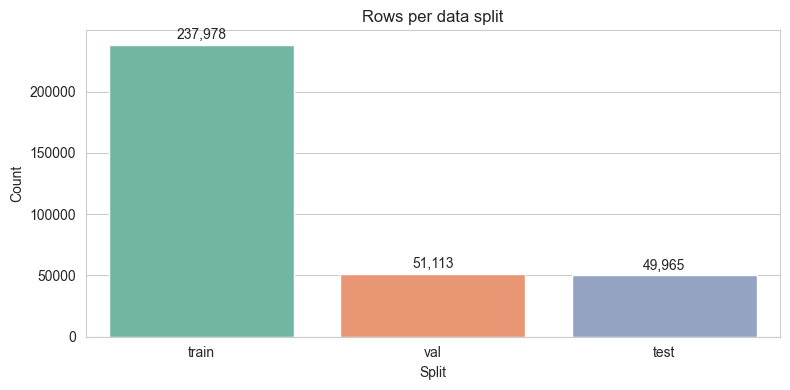

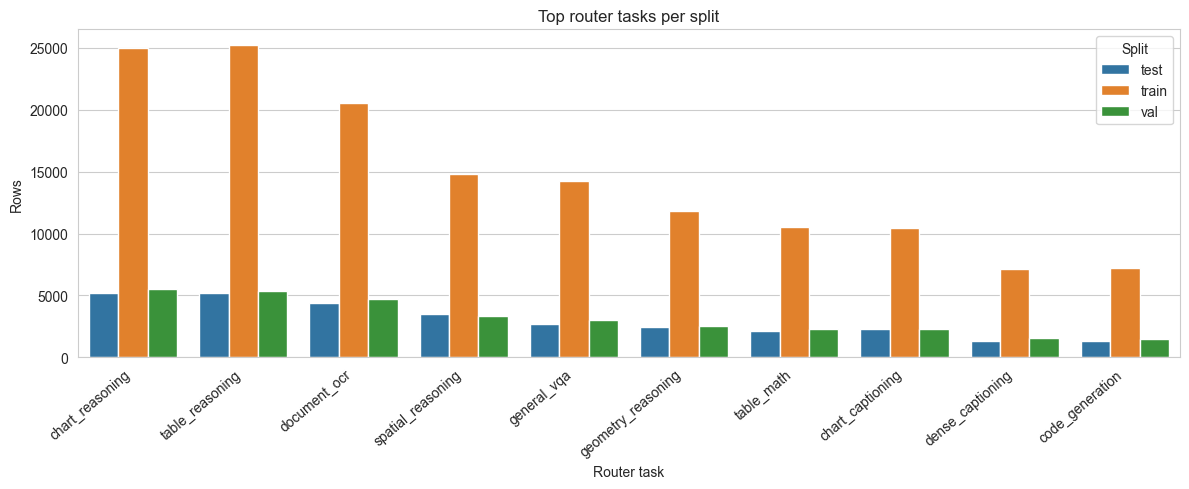

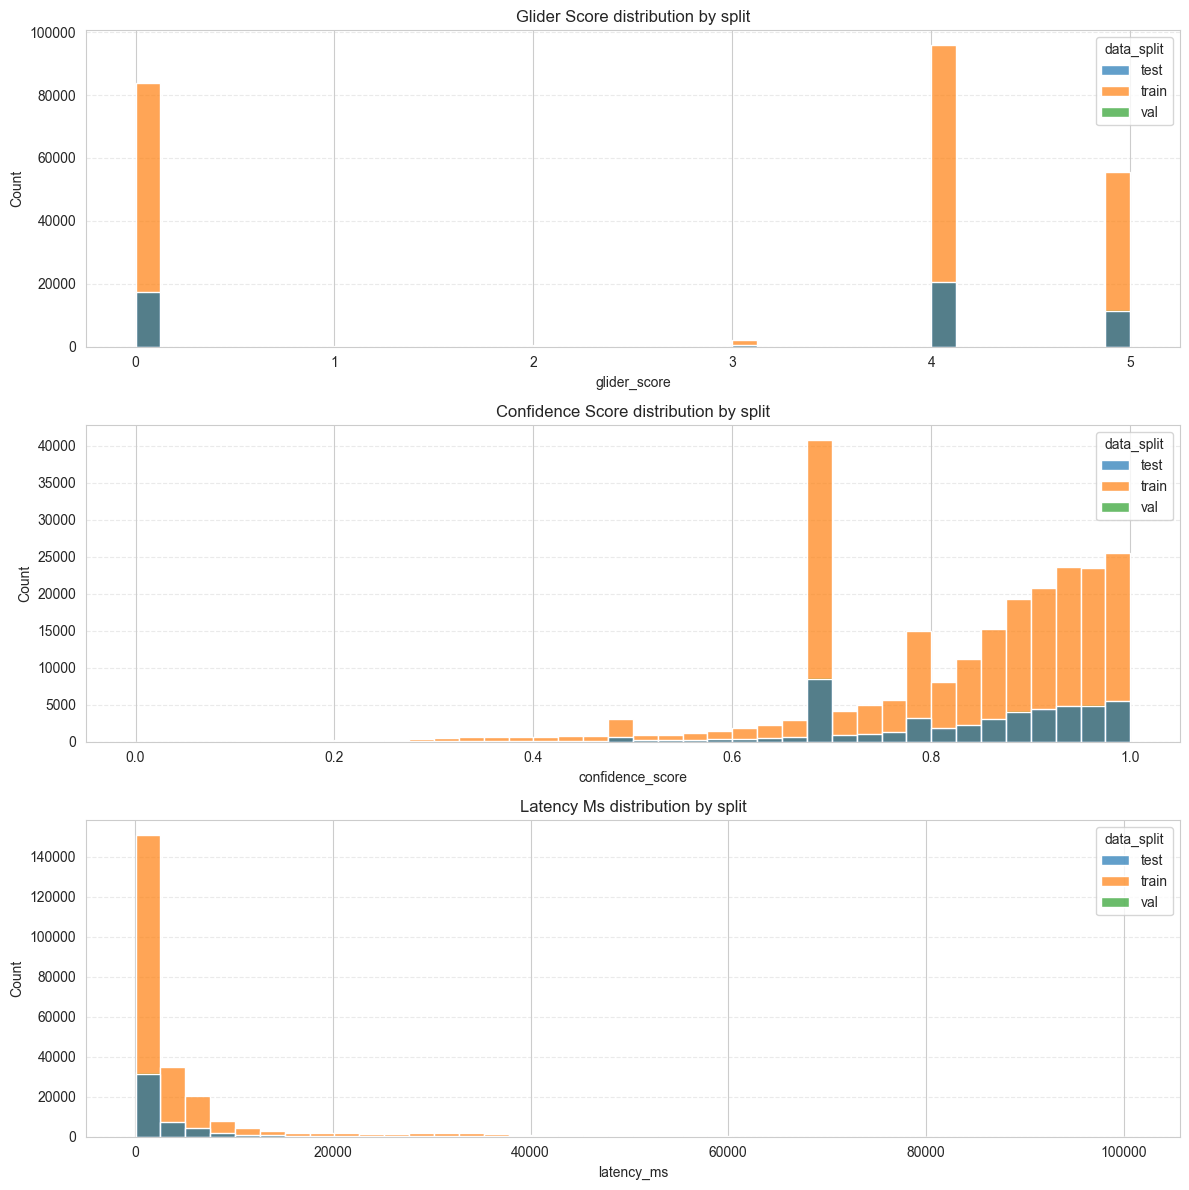

In [27]:
# Visualize split coverage and task/metric distributions
if 'data_split' not in df_clean.columns:
    print("⚠️  'data_split' column missing; skip visualization of splits.")
else:
    split_counts = df_clean['data_split'].value_counts()
    ordered_splits = ['train', 'val', 'test']
    ordered_splits += [split for split in split_counts.index if split not in ordered_splits]
    split_counts = split_counts.reindex(ordered_splits).fillna(0).astype(int)

    print("[Data split counts]")
    print(split_counts)

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(x=split_counts.index, y=split_counts.values, palette='Set2', ax=ax)
    ax.set_title('Rows per data split')
    ax.set_ylabel('Count')
    ax.set_xlabel('Split')
    y_offset = split_counts.max() * 0.01 if split_counts.max() > 0 else 1
    for idx, value in enumerate(split_counts.values):
        ax.text(idx, value + y_offset, f"{value:,}", ha='center', va='bottom')
    plt.tight_layout()

    if 'router_task' in df_clean.columns:
        task_counts = df_clean['router_task'].value_counts()
        top_tasks = task_counts.head(10).index.tolist()
        print("Top router tasks (by rows):")
        print(task_counts.head(8))

        task_split_df = (
            df_clean[df_clean['router_task'].isin(top_tasks)]
            .groupby(['router_task', 'data_split'])
            .size()
            .reset_index(name='count')
        )

        fig, ax = plt.subplots(figsize=(12, 5))
        sns.barplot(
            data=task_split_df,
            x='router_task',
            y='count',
            hue='data_split',
            order=top_tasks,
            ax=ax,
        )
        ax.set_title('Top router tasks per split')
        ax.set_ylabel('Rows')
        ax.set_xlabel('Router task')
        ax.legend(title='Split')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
        plt.tight_layout()
    else:
        print("⚠️  'router_task' column missing; skipping task-level chart.")

    metric_columns = [col for col in ['glider_score', 'confidence_score', 'latency_ms', 'cost_usd'] if col in df_clean.columns]
    if metric_columns:
        fig, axes = plt.subplots(len(metric_columns), 1, figsize=(12, 4 * len(metric_columns)), sharex=False)
        if len(metric_columns) == 1:
            axes = [axes]
        for col, ax in zip(metric_columns, axes):
            sns.histplot(
                data=df_clean,
                x=col,
                hue='data_split',
                multiple='layer',
                stat='count',
                bins=40,
                edgecolor='w',
                alpha=0.7,
                ax=ax,
            )
            ax.set_title(f"{col.replace('_', ' ').title()} distribution by split")
            ax.set_ylabel('Count')
            ax.grid(True, axis='y', linestyle='--', alpha=0.4)
        plt.tight_layout()
    else:
        print("⚠️  No numeric metrics found for histogram visualization.")


## 7. Save to Local SQLite Database

In [28]:
# Save to SQLite and Parquet
print(f"\n{'='*80}")
print("SAVING DATA")
print(f"{'='*80}\n")

# 1. Save to SQLite
print(f"[Saving to SQLite]")
print(f"  Path: {LOCAL_DB_PATH}")
print(f"  Table: {TABLE_NAME}")
print(f"  Rows: {len(df_clean):,}")
print(f"  Columns: {len(df_clean.columns)}")

save_to_sqlite(
    df=df_clean,
    db_path=LOCAL_DB_PATH,
    table_name=TABLE_NAME,
    if_exists='replace',
)

# 2. Save to Parquet
print(f"\n[Saving to Parquet]")
print(f"  Path: {PARQUET_PATH}")
try:
    df_clean.to_parquet(PARQUET_PATH, index=False)
    print("  ✓ Parquet export successful")
except Exception as e:
    print(f"  ❌ Parquet export failed: {e}")

# Get file size
file_size_mb = LOCAL_DB_PATH.stat().st_size / (1024 * 1024)

print(f"\n{'='*80}")
print("SAVE COMPLETE")
print(f"{'='*80}")
print(f"  Database file: {LOCAL_DB_PATH}")
print(f"  File size: {file_size_mb:.2f} MB")
print(f"  Rows saved: {len(df_clean):,}")
print(f"  Table name: {TABLE_NAME}")
print(f"  Parquet: {PARQUET_PATH}")
print(f"{'='*80}")

print(f"\n✓ Local database ready!")

2025-12-08 19:50:39,655 - db_utils - INFO - Created SQLite engine for ../data/vlm_router_cache.db
2025-12-08 19:50:39,655 - db_utils - INFO - Saving 339056 rows to ../data/vlm_router_cache.db:vlm_profiles



SAVING DATA

[Saving to SQLite]
  Path: ../data/vlm_router_cache.db
  Table: vlm_profiles
  Rows: 339,056
  Columns: 37


2025-12-08 19:50:44,239 - db_utils - INFO - ✓ Saved to ../data/vlm_router_cache.db



[Saving to Parquet]
  Path: ../data/router_profiles_with_utility.parquet
  ✓ Parquet export successful

SAVE COMPLETE
  Database file: ../data/vlm_router_cache.db
  File size: 230.52 MB
  Rows saved: 339,056
  Table name: vlm_profiles
  Parquet: ../data/router_profiles_with_utility.parquet

✓ Local database ready!


## 8. Verify Local Database

In [29]:
# Test loading from SQLite
print(f"\n{'='*80}")
print("VERIFYING LOCAL DATABASE")
print(f"{'='*80}\n")

print("[Loading from SQLite (verification)]")
df_verify = load_from_sqlite(
    db_path=LOCAL_DB_PATH,
    table_name=TABLE_NAME,
    limit=10,  # Just load 10 rows for verification
)

print(f"\n[Verification Results]")
print(f"  Loaded {len(df_verify)} rows (limit=10)")
print(f"  Columns match: {set(df_verify.columns) == set(df_clean.columns)}")

print(f"\n[Sample Data]")
display(df_verify.head())

print(f"\n✓ Local database verified successfully!")

2025-12-08 19:50:44,857 - db_utils - INFO - Created SQLite engine for ../data/vlm_router_cache.db
2025-12-08 19:50:44,857 - db_utils - INFO - Loading from ../data/vlm_router_cache.db:vlm_profiles
2025-12-08 19:50:44,857 - db_utils - INFO -   Limit: 10
2025-12-08 19:50:44,859 - db_utils - INFO - Loaded 10 rows
2025-12-08 19:50:44,859 - db_utils - INFO -   Unique samples: 10
2025-12-08 19:50:44,859 - db_utils - INFO -   Unique models: 1
2025-12-08 19:50:44,859 - db_utils - INFO -   Data splits: {'train': 6, 'test': 3, 'val': 1}



VERIFYING LOCAL DATABASE

[Loading from SQLite (verification)]

[Verification Results]
  Loaded 10 rows (limit=10)
  Columns match: True

[Sample Data]


,sample_id,run_id,source_config,source_dataset,source_index,router_task,ground_truth_type,data_split,prompt_text,ground_truth,...,total_tokens,utility_accuracy,utility_cheap,utility_fast,utility_balanced,cost_norm_new,lat_norm,glider_score,judge_molmo_score,judge_molmo_rank_group
0,aokvqa_796_8644de03,run_20251207_225050,aokvqa,cauldron,796,knowledge_vqa,exact,test,How many women are holding umbrellas in front ...,Two.,...,493,0.0,0.986553,0.968584,0.488784,0.013447,0.031416,5.0,NaN,NaN
1,docvqa_270_ca57d063,run_20251207_225050,docvqa,cauldron,270,document_ocr,exact,train,What is the title of the document?\nEnsure bre...,Hazard and Exposure Criteria for Prioritizatio...,...,4876,0.0,0.866107,0.976502,0.460652,0.133893,0.023498,5.0,10.0,1.0
2,docvqa_780_af6b5410,run_20251207_225050,docvqa,cauldron,780,document_ocr,exact,train,What is the name of association in statement?\...,Food industry association.,...,3165,0.0,0.913126,0.952448,0.466393,0.086874,0.047552,5.0,9.0,1.0
3,hateful_memes_318_89d84476,run_20251207_225050,hateful_memes,cauldron,318,meme_classification,exact,train,Can this meme be interpreted as derogatory?\nA...,No.,...,647,0.0,0.982321,0.996046,0.494592,0.017679,0.003954,0.0,10.0,1.0
4,ai2d_585_e4327c29,run_20251208_023438,ai2d,cauldron,585,diagram_reasoning,mc,train,Question: At what stage does a butterfly lay e...,Answer: C,...,115,0.0,0.996940,0.986229,0.495792,0.003060,0.013771,4.0,10.0,1.0



✓ Local database verified successfully!


## 9. Test Loading by Split

In [30]:
# Test loading each split
if 'data_split' in df_clean.columns:
    print(f"\n{'='*80}")
    print("TESTING SPLIT LOADING")
    print(f"{'='*80}\n")

    for split in ['train', 'val', 'test']:
        print(f"[Loading {split} split]")
        df_split = load_from_sqlite(
            db_path=LOCAL_DB_PATH,
            table_name=TABLE_NAME,
            data_split=split,
            limit=5,
        )
        print(f"  ✓ Loaded {len(df_split)} rows (limit=5)")
        print()

    print(f"✓ All splits can be loaded successfully!")
else:
    print(f"\nSkipping split loading test (no data_split column)")

2025-12-08 19:50:44,898 - db_utils - INFO - Created SQLite engine for ../data/vlm_router_cache.db
2025-12-08 19:50:44,898 - db_utils - INFO - Loading from ../data/vlm_router_cache.db:vlm_profiles
2025-12-08 19:50:44,898 - db_utils - INFO -   Filtering by data_split: train
2025-12-08 19:50:44,898 - db_utils - INFO -   Limit: 5
2025-12-08 19:50:44,900 - db_utils - INFO - Loaded 5 rows
2025-12-08 19:50:44,901 - db_utils - INFO -   Unique samples: 5
2025-12-08 19:50:44,901 - db_utils - INFO -   Unique models: 1
2025-12-08 19:50:44,901 - db_utils - INFO -   Data splits: {'train': 5}
2025-12-08 19:50:44,902 - db_utils - INFO - Created SQLite engine for ../data/vlm_router_cache.db
2025-12-08 19:50:44,902 - db_utils - INFO - Loading from ../data/vlm_router_cache.db:vlm_profiles
2025-12-08 19:50:44,902 - db_utils - INFO -   Filtering by data_split: val
2025-12-08 19:50:44,902 - db_utils - INFO -   Limit: 5
2025-12-08 19:50:44,904 - db_utils - INFO - Loaded 5 rows
2025-12-08 19:50:44,905 - db_ut


TESTING SPLIT LOADING

[Loading train split]
  ✓ Loaded 5 rows (limit=5)

[Loading val split]
  ✓ Loaded 5 rows (limit=5)

[Loading test split]
  ✓ Loaded 5 rows (limit=5)

✓ All splits can be loaded successfully!


## 10. Create Metadata File

In [31]:
# Save metadata about the database
import json

metadata = {
    'created_at': datetime.now().isoformat(),
    'source_host': db_config.host,
    'source_database': db_config.name,
    'total_rows': int(len(df_clean)),
    'unique_samples': int(df_clean['sample_id'].nunique()),
    'unique_models': int(df_clean['model_name'].nunique()),
    'models': sorted(df_clean['model_name'].unique().tolist()),
    'columns': df_clean.columns.tolist(),
    'table_name': TABLE_NAME,
    'cleaning_stats': cleaning_stats,
}

if 'data_split' in df_clean.columns:
    metadata['split_counts'] = df_clean['data_split'].value_counts().to_dict()

metadata_path = DATA_DIR / "vlm_router_cache_metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"\n[Metadata Saved]")
print(f"  Path: {metadata_path}")
print(f"\nMetadata:")
print(json.dumps(metadata, indent=2))


[Metadata Saved]
  Path: ../data/vlm_router_cache_metadata.json

Metadata:
{
  "created_at": "2025-12-08T19:50:44.940585",
  "source_host": "localhost",
  "source_database": "vlmrouter",
  "total_rows": 339056,
  "unique_samples": 67935,
  "unique_models": 5,
  "models": [
    "deepseek_ocr",
    "gemma_3_27b",
    "qwen2_5_vl_3b",
    "qwen2_5_vl_7b",
    "qwen3_vl_8b_thinking"
  ],
  "columns": [
    "sample_id",
    "run_id",
    "source_config",
    "source_dataset",
    "source_index",
    "router_task",
    "ground_truth_type",
    "data_split",
    "prompt_text",
    "ground_truth",
    "txt_prompt_length_chars",
    "txt_prompt_length_words",
    "txt_question_type",
    "txt_has_mc_options",
    "response_id",
    "model_name",
    "model_prefix",
    "ok",
    "is_correct",
    "score_exact_match_normalized",
    "score_numeric_match",
    "score_mc_letter_match",
    "confidence_score",
    "estimated_cost_usd",
    "latency_ms",
    "input_tokens",
    "output_tokens",
   

## 11. Usage Instructions

In [32]:
# Print usage instructions
print(f"\n{'='*80}")
print("SETUP COMPLETE - HOW TO USE")
print(f"{'='*80}\n")

print("The local database is ready! In your training notebooks (02, 03, 04), replace:")
print()
print("  # OLD: Load from PostgreSQL")
print("  df_profiles = load_profiles_real_schema(")
print("      db_config=db_config,")
print("      data_split='train',")
print("  )")
print()
print("  # NEW: Load from local SQLite")
print("  from db_utils import load_from_sqlite")
print()
print(f"  LOCAL_DB_PATH = Path('../data/vlm_router_cache.db')")
print()
print("  df_profiles = load_from_sqlite(")
print("      db_path=LOCAL_DB_PATH,")
print("      table_name='vlm_profiles',")
print("      data_split='train',  # or 'val', 'test', or None for all")
print("  )")
print()
print(f"{'='*80}")
print(f"\n✓ You can now run notebooks 02, 03, 04 using the local database!")
print(f"\n💡 Tip: Re-run this notebook whenever you want to refresh the local cache.")
print(f"{'='*80}")


SETUP COMPLETE - HOW TO USE

The local database is ready! In your training notebooks (02, 03, 04), replace:

  # OLD: Load from PostgreSQL
  df_profiles = load_profiles_real_schema(
      db_config=db_config,
      data_split='train',
  )

  # NEW: Load from local SQLite
  from db_utils import load_from_sqlite

  LOCAL_DB_PATH = Path('../data/vlm_router_cache.db')

  df_profiles = load_from_sqlite(
      db_path=LOCAL_DB_PATH,
      table_name='vlm_profiles',
      data_split='train',  # or 'val', 'test', or None for all
  )


✓ You can now run notebooks 02, 03, 04 using the local database!

💡 Tip: Re-run this notebook whenever you want to refresh the local cache.


## Summary

This notebook:
1. ✅ Connected to PostgreSQL
2. ✅ Fetched all profiling data
3. ✅ Validated data quality
4. ✅ Cleaned missing values
5. ✅ Validated train/val/test splits
6. ✅ Visualized split coverage and key metrics
7. ✅ Saved to local SQLite database
8. ✅ Verified the local database works

### Files Created

- `../data/vlm_router_cache.db` - Local SQLite database with all data
- `../data/vlm_router_cache_metadata.json` - Metadata about the cache

### Next Steps

1. Update notebooks 02, 03, 04 to use `load_from_sqlite()` instead of `load_profiles_real_schema()`
2. Run training notebooks - they'll be much faster!
3. Re-run this notebook whenever you need to refresh the cache with new data
